# Turn prediction — ZOH prediction quality vs anticipation lead (90-degree turn campaign, Phase A)

The stakeholder's own ask, verbatim: *"charts and graphs in the Jupyter
notebook ... plots of our instantaneous telemetry ... versus where my
predictions are? Time-shifted. I want to see what the root-mean-square
error between those is."*

This notebook answers that directly, using `App::StateEstimator`'s own
zero-order-hold (ZOH) prediction math (`src/firm/app/state_estimator.cpp`,
sprint 117) — reimplemented independently in pure Python
(`src/tests/tools/one_step_ahead.py`, sprint 117-006) so the comparison is
a real check, not the estimator agreeing with itself:

1. **Capture** a turn-heavy sim session — 8 isolated 90-degree turns (both
   directions) plus a full TOUR_1 run — to a `tlm_log`-shaped CSV
   (`src/tests/bench/turn_prediction_capture.py`, this campaign).
2. **Time-shifted prediction overlay**: measured heading (and wheel
   position) vs the SAME ZOH prediction, shifted forward by Δ = one cycle
   (50ms) and by a sweep of leads 0–300ms — "prediction made at t−Δ,
   evaluated at t" (`one_step_ahead.shifted_prediction_walk()`, new this
   notebook's own campaign).
3. **RMS(Δ)** — the residual RMS as a function of the shift Δ: the curve
   that says how far ahead this ZOH prediction can be trusted.
4. **Measured stop-detection lag / overshoot** — for each of the 8 isolated
   turns, the time between the MEASURED heading crossing the commanded
   90-degree threshold and the robot's own angular rate actually settling
   back to ~0, and the resulting overshoot in degrees
   (`src/tests/tools/turn_events.py`, this campaign).
5. **Conclusion**: a recommended anticipation lead (`stop_lead`, ms) for
   sim, derived directly from (3) and (4) above — the number Phase B
   (`App::MoveQueue` + `App::StateEstimator::bodyAt()`) uses as its
   fail-closed boot default.

**Established diagnosis this notebook is measuring, not re-deriving**
(already verified against real bench/sim behavior, see
`clasi/issues/angle-stop-overshoot-61-73-percent-on-hardware.md` and
`_button_acceptance_support.py`'s own tolerance-model docstring): turns
overshoot by a roughly constant ~150–180ms stop-detection/actuation lag
(hardware), independent of the commanded angle — `Motion::StopCondition`
fires the cycle the heading CROSSES the threshold, but the wheels keep
coasting through the write-path's shaped ramp plus actuation lag before
actually stopping. This notebook quantifies the SAME mechanism directly
from sim telemetry.

**Default data source:** a sim capture generated fresh by this notebook
(`turn_prediction_capture.py`), so it runs end to end with no external file
dependency — matching `estimator_validation.ipynb`'s own precedent.

In [1]:
# Parameters -------------------------------------------------------------
# CSV_PATH/MANIFEST_PATH: paths to a previously-captured turn_prediction_capture.py
# CSV + manifest pair. None (default) -> generate a fresh sim capture in the
# cell below. Set both to a bench-captured pair to validate against real
# hardware instead -- no other cell needs to change.
CSV_PATH = None
MANIFEST_PATH = None

# Sim-capture-only knobs (ignored once CSV_PATH/MANIFEST_PATH are both set).
SIM_ROBOT_JSON = "tovez_nocal.json"                              # under data/robots/
SIM_CAPTURE_CSV = "out/turn_prediction_nb_capture.csv"            # relative to this notebook's own directory
SIM_CAPTURE_MANIFEST = "out/turn_prediction_nb_manifest.json"     # relative to this notebook's own directory

# The shift/lead sweep swept for the RMS(shift) curve -- 0-300ms per the
# stakeholder's own ask, at the sim's own 50ms cycle granularity.
SHIFT_SWEEP_MS = list(range(0, 301, 10))
ONE_CYCLE_MS = 50.0  # [ms] SimLoop.step()'s/robot_loop's own per-cycle advance

In [2]:
from __future__ import annotations

import csv
import json
import math
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

NOTEBOOK_DIR = pathlib.Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parents[2]  # src/tests/notebooks -> src/tests -> src -> repo root
TOOLS_DIR = REPO_ROOT / "src" / "tests" / "tools"
BENCH_DIR = REPO_ROOT / "src" / "tests" / "bench"

for _p in (TOOLS_DIR, BENCH_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import one_step_ahead as osa   # ZOH prediction/RMS math -- sprint 117-006, extended this campaign
import turn_events as te       # stop-detection lag/overshoot measurement -- this campaign

print(f"repo root:      {REPO_ROOT}")
print(f"one_step_ahead: {osa.__file__}")
print(f"turn_events:    {te.__file__}")

repo root:      /Volumes/Proj/proj/RobotProjects/radio-robot-elite
one_step_ahead: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/tools/one_step_ahead.py
turn_events:    /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/tools/turn_events.py


## 1. Load the data — sim capture (fresh) or a previously-captured pair

In [3]:
if CSV_PATH is None or MANIFEST_PATH is None:
    capture_csv = (NOTEBOOK_DIR / SIM_CAPTURE_CSV).resolve()
    capture_manifest = (NOTEBOOK_DIR / SIM_CAPTURE_MANIFEST).resolve()
    capture_csv.parent.mkdir(parents=True, exist_ok=True)
    script = BENCH_DIR / "turn_prediction_capture.py"
    robot_json = REPO_ROOT / "data" / "robots" / SIM_ROBOT_JSON

    print(f"CSV_PATH/MANIFEST_PATH not set -- generating a fresh sim capture:\n"
          f"  {script.name} --csv {capture_csv} --manifest {capture_manifest} --robot-json {robot_json}")
    result = subprocess.run(
        [sys.executable, str(script), "--csv", str(capture_csv), "--manifest", str(capture_manifest),
         "--robot-json", str(robot_json)],
        cwd=REPO_ROOT, capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr, file=sys.stderr)
    assert result.returncode == 0, f"turn_prediction_capture.py failed (exit {result.returncode})"
    csv_path, manifest_path = capture_csv, capture_manifest
else:
    csv_path, manifest_path = pathlib.Path(CSV_PATH).resolve(), pathlib.Path(MANIFEST_PATH).resolve()

print(f"csv_path:      {csv_path}")
print(f"manifest_path: {manifest_path}")
assert csv_path.is_file(), f"CSV not found: {csv_path}"
assert manifest_path.is_file(), f"manifest not found: {manifest_path}"

CSV_PATH/MANIFEST_PATH not set -- generating a fresh sim capture:
  turn_prediction_capture.py --csv /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/turn_prediction_nb_capture.csv --manifest /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/turn_prediction_nb_manifest.json --robot-json /Volumes/Proj/proj/RobotProjects/radio-robot-elite/data/robots/tovez_nocal.json


wrote 717 rows to /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/turn_prediction_nb_capture.csv
wrote 8 turn manifest entries (+1 other) to /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/turn_prediction_nb_manifest.json
TOUR_1: completed=True stopped_at=None outcome=None

csv_path:      /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/turn_prediction_nb_capture.csv
manifest_path: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/turn_prediction_nb_manifest.json


In [4]:
with open(csv_path, newline="") as f:
    rows = list(csv.DictReader(f))
manifest = json.loads(manifest_path.read_text())

turn_manifest = [m for m in manifest if m.get("kind") == "turn"]
tour_summary = next((m for m in manifest if m.get("kind") == "tour_summary"), None)

print(f"{len(rows)} TLM rows loaded ({csv_path.name})")
print(f"{len(turn_manifest)} isolated 90-degree turns in manifest")
if tour_summary is not None:
    print(f"TOUR_1: completed={tour_summary['completed']} "
          f"stopped_at={tour_summary['stopped_at']} outcome={tour_summary['stopped_outcome']}")

df = pd.DataFrame(rows).apply(pd.to_numeric, errors="coerce")
df[["now", "mode", "pose_theta", "twist_omega", "enc_left_velocity", "enc_right_velocity"]].head(8)

717 TLM rows loaded (turn_prediction_nb_capture.csv)
8 isolated 90-degree turns in manifest
TOUR_1: completed=True stopped_at=None outcome=None


,now,mode,pose_theta,twist_omega,enc_left_velocity,enc_right_velocity
0,2300,NaN,0,0,0.000000,0.000000
1,2400,NaN,0,0,0.000000,0.000000
2,2450,NaN,0,0,0.000000,0.000000
3,2500,NaN,0,0,0.000000,0.000000
4,2550,NaN,0,0,0.000000,0.000000
5,2650,NaN,6,396,-12.687322,38.061966
6,2700,NaN,176,1585,-105.727669,97.269478
7,2750,NaN,631,1861,-119.824722,118.415009


## 2. Parse the streams

`heading_stream_from_rows()`/`wheel_stream_from_rows()` (both `one_step_ahead.py`,
sprint 117-006) convert the raw CSV rows into the parallel `(times, values,
rates)` arrays every prediction/RMS function below consumes — heading/omega
already unit-converted to radians / rad/s; wheel position/velocity in mm /
mm/s.

In [5]:
head_t, heading, omega = osa.heading_stream_from_rows(rows)
left_t, left_pos, left_vel = osa.wheel_stream_from_rows(rows, side="left")
right_t, right_pos, right_vel = osa.wheel_stream_from_rows(rows, side="right")

print(f"heading stream: {len(head_t)} samples, span [{head_t[0]:.0f}, {head_t[-1]:.0f}] ms")
print(f"left wheel stream: {len(left_t)} samples")
print(f"right wheel stream: {len(right_t)} samples")

heading stream: 717 samples, span [2300, 40550] ms
left wheel stream: 717 samples
right wheel stream: 717 samples


## 3. Time-shifted ZOH prediction overlay — measured vs predicted

For a representative window (the FIRST captured turn), overlays the
MEASURED heading against the ZOH prediction made Δ ms earlier and
extrapolated forward (`one_step_ahead.shifted_prediction_walk()`) — Δ =
one cycle (50ms), then a small multiple showing how the SAME overlay
degrades as Δ grows toward 300ms. This is the direct visual answer to
"plots of our instantaneous telemetry ... versus where my predictions
are, time-shifted".

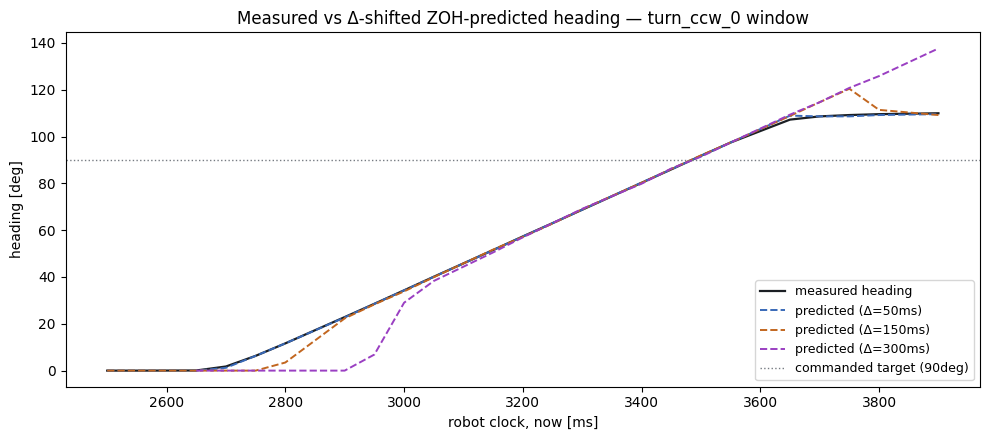

In [6]:
_first_turn = turn_manifest[0]
_window_start = _first_turn["issue_now_ms"]
_window_end = turn_manifest[1]["issue_now_ms"] if len(turn_manifest) > 1 else _window_start + 3000.0

_win_idx = [i for i, t in enumerate(head_t) if _window_start <= t <= _window_end]
_win_t = [head_t[i] for i in _win_idx]
_win_h_deg = [math.degrees(heading[i]) for i in _win_idx]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(_win_t, _win_h_deg, "-", color="#1b1f24", lw=1.6, label="measured heading")

_overlay_colors = {50.0: "#3969b8", 150.0: "#c2661f", 300.0: "#9a3fc2"}
for shift_ms, color in _overlay_colors.items():
    walk = osa.shifted_prediction_walk(head_t, heading, omega, shift_ms)
    pts = [(r.time, math.degrees(r.predicted)) for r in walk if _window_start <= r.time <= _window_end]
    if not pts:
        continue
    pt_t, pt_h = zip(*pts)
    ax.plot(pt_t, pt_h, "--", color=color, lw=1.4, label=f"predicted (Δ={shift_ms:.0f}ms)")

ax.axhline(math.degrees(heading[_win_idx[0]]) + math.degrees(_first_turn["target_rad"]),
          color="#767b82", lw=1.0, ls=":", label="commanded target (90deg)")
ax.set_xlabel("robot clock, now [ms]")
ax.set_ylabel("heading [deg]")
ax.set_title(f"Measured vs Δ-shifted ZOH-predicted heading — {_first_turn['label']} window")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 4. Residual time-series — Δ = one cycle (50ms), whole session

The SAME shifted-prediction walk, Δ = one cycle, over the WHOLE captured
session (all 8 turns + the TOUR_1 run) — the residual (`actual −
predicted`) is the direct one-step-ahead prediction error the firmware's
own `StateEstimator::bodyAt()` would carry at minimum lead.

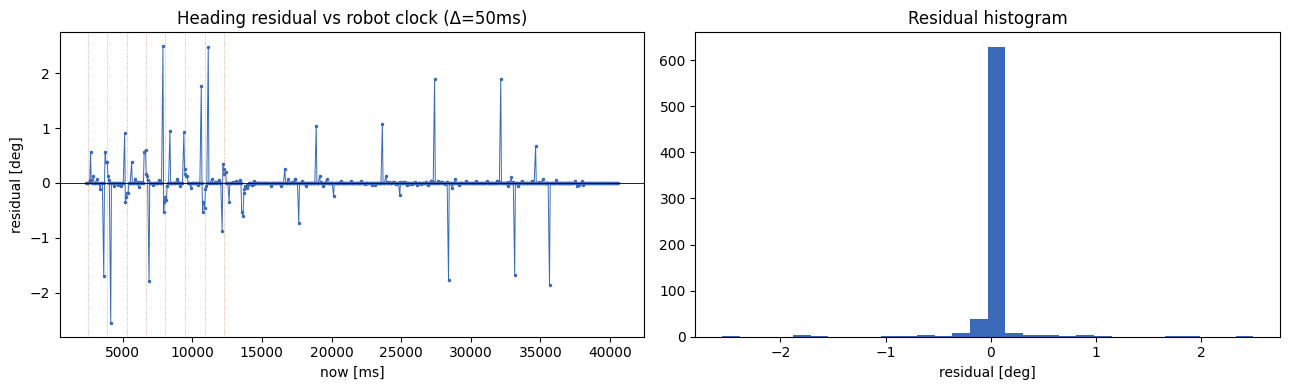

RMS heading residual @ Δ=50ms: 0.2797 deg (0.004882 rad), n=716


In [7]:
walk_one_cycle = osa.shifted_prediction_walk(head_t, heading, omega, ONE_CYCLE_MS)
res_t = [r.time for r in walk_one_cycle]
res_deg = [math.degrees(r.residual) for r in walk_one_cycle]

fig, (ax_ts, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))
ax_ts.plot(res_t, res_deg, ".-", ms=3, lw=0.7, color="#3969b8")
ax_ts.axhline(0, color="k", lw=0.6)
for m in turn_manifest:
    ax_ts.axvline(m["issue_now_ms"], color="#c2661f", lw=0.6, ls=":", alpha=0.6)
ax_ts.set_title(f"Heading residual vs robot clock (Δ={ONE_CYCLE_MS:.0f}ms)")
ax_ts.set_xlabel("now [ms]")
ax_ts.set_ylabel("residual [deg]")

ax_hist.hist(res_deg, bins=30, color="#3969b8")
ax_hist.set_title("Residual histogram")
ax_hist.set_xlabel("residual [deg]")
fig.tight_layout()
plt.show()

print(f"RMS heading residual @ Δ={ONE_CYCLE_MS:.0f}ms: {osa.rms(res_deg):.4f} deg "
      f"({osa.rms([r.residual for r in walk_one_cycle]):.6f} rad), n={len(walk_one_cycle)}")

## 5. RMS(Δ) — the key curve: how far ahead can this prediction be trusted?

`one_step_ahead.rms_vs_shift()` sweeps Δ from 0–300ms and reports the RMS
residual at each — for BOTH heading (drives the angle-stop anticipation,
Phase B) and left-wheel position (drives the distance-stop anticipation,
Phase B's own "distance stops get the same treatment"). Plotted as two
single-axis charts (never one dual-axis chart — the two streams have
different units, deg vs mm).

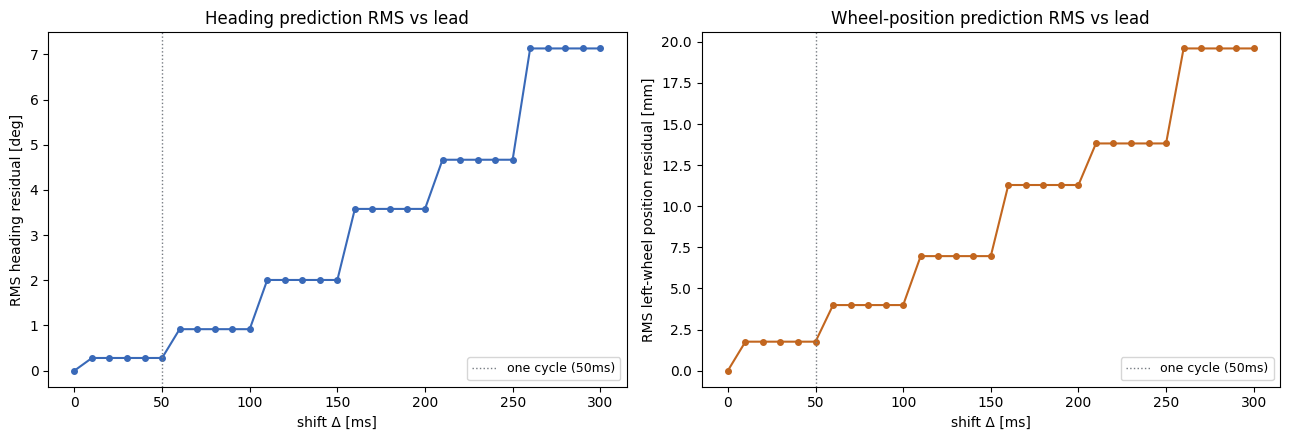

,heading_rms_deg,wheel_position_rms_mm
shift_ms,,
0,0.0000,0.0000
10,0.2797,1.7601
20,0.2797,1.7601
30,0.2797,1.7601
40,0.2797,1.7601
50,0.2797,1.7601
60,0.9172,3.9872
70,0.9172,3.9872
80,0.9172,3.9872


In [8]:
heading_rms_vs_shift = osa.rms_vs_shift(head_t, heading, omega, SHIFT_SWEEP_MS)
wheel_rms_vs_shift = osa.rms_vs_shift(left_t, left_pos, left_vel, SHIFT_SWEEP_MS)

fig, (ax_h, ax_w) = plt.subplots(1, 2, figsize=(13, 4.5))

ax_h.plot(SHIFT_SWEEP_MS, [math.degrees(heading_rms_vs_shift[s]) for s in SHIFT_SWEEP_MS],
         "-o", ms=4, color="#3969b8")
ax_h.axvline(ONE_CYCLE_MS, color="#767b82", lw=1.0, ls=":", label="one cycle (50ms)")
ax_h.set_xlabel("shift Δ [ms]")
ax_h.set_ylabel("RMS heading residual [deg]")
ax_h.set_title("Heading prediction RMS vs lead")
ax_h.legend(fontsize=9)

ax_w.plot(SHIFT_SWEEP_MS, [wheel_rms_vs_shift[s] for s in SHIFT_SWEEP_MS],
         "-o", ms=4, color="#c2661f")
ax_w.axvline(ONE_CYCLE_MS, color="#767b82", lw=1.0, ls=":", label="one cycle (50ms)")
ax_w.set_xlabel("shift Δ [ms]")
ax_w.set_ylabel("RMS left-wheel position residual [mm]")
ax_w.set_title("Wheel-position prediction RMS vs lead")
ax_w.legend(fontsize=9)

fig.tight_layout()
plt.show()

rms_table = pd.DataFrame({
    "shift_ms": SHIFT_SWEEP_MS,
    "heading_rms_deg": [math.degrees(heading_rms_vs_shift[s]) for s in SHIFT_SWEEP_MS],
    "wheel_position_rms_mm": [wheel_rms_vs_shift[s] for s in SHIFT_SWEEP_MS],
}).set_index("shift_ms")
rms_table.round(4)

## 6. Measured stop-detection lag and overshoot, per turn

`turn_events.find_turn_events()` measures, independently from the
firmware's own internal stop-condition decision — purely from measured
heading/omega — for each of the 8 isolated turns: `t_cross` (measured
heading reaches the 90-degree threshold), `t_settle` (angular rate
actually settles back to ~0 afterward), `lag = t_settle - t_cross`, and
`overshoot` (heading traveled past the threshold by the time it settled).

In [9]:
events = te.find_turn_events(head_t, heading, omega, manifest)
print(f"{len(events)}/{len(turn_manifest)} turns yielded a measured crossing+settle event")

events_table = pd.DataFrame([{
    "label": e.label, "direction": "CCW" if e.direction > 0 else "CW",
    "t_cross_ms": e.t_cross, "t_settle_ms": e.t_settle,
    "lag_ms": e.lag, "overshoot_deg": math.degrees(e.overshoot),
} for e in events])
events_table

8/8 turns yielded a measured crossing+settle event


,label,direction,t_cross_ms,t_settle_ms,lag_ms,overshoot_deg
0,turn_ccw_0,CCW,3500.0,3700.0,200.0,18.62
1,turn_cw_0,CW,4900.0,5150.0,250.0,18.57
2,turn_ccw_1,CCW,6300.0,6500.0,200.0,18.03
3,turn_cw_1,CW,7700.0,7900.0,200.0,18.03
4,turn_ccw_2,CCW,9150.0,9300.0,150.0,17.84
5,turn_cw_2,CW,10500.0,10700.0,200.0,18.03
6,turn_ccw_3,CCW,11900.0,12150.0,250.0,18.60
7,turn_cw_3,CW,13300.0,13500.0,200.0,18.03


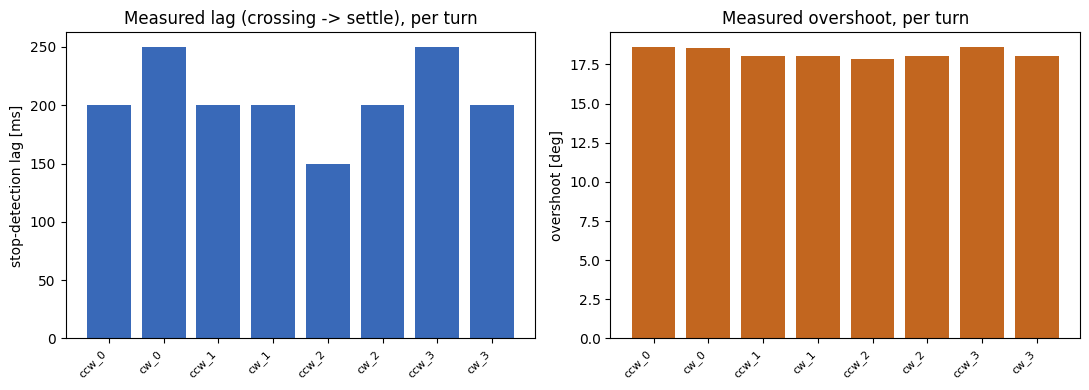

lag/overshoot distribution summary:
{
  "count": 8,
  "lag_ms": {
    "min": 150.0,
    "max": 250.0,
    "mean": 206.25
  },
  "overshoot_deg": {
    "min": 17.839999999999996,
    "max": 18.62,
    "mean": 18.218749999999996
  }
}


In [10]:
fig, (ax_lag, ax_over) = plt.subplots(1, 2, figsize=(11, 4))

_x = list(range(len(events)))
ax_lag.bar(_x, [e.lag for e in events], color="#3969b8")
ax_lag.set_xticks(_x)
ax_lag.set_xticklabels([e.label.replace("turn_", "") for e in events], rotation=45, ha="right", fontsize=8)
ax_lag.set_ylabel("stop-detection lag [ms]")
ax_lag.set_title("Measured lag (crossing -> settle), per turn")

ax_over.bar(_x, [math.degrees(e.overshoot) for e in events], color="#c2661f")
ax_over.set_xticks(_x)
ax_over.set_xticklabels([e.label.replace("turn_", "") for e in events], rotation=45, ha="right", fontsize=8)
ax_over.set_ylabel("overshoot [deg]")
ax_over.set_title("Measured overshoot, per turn")

fig.tight_layout()
plt.show()

summary = te.summarize_lag_and_overshoot(events)
print("lag/overshoot distribution summary:")
print(json.dumps(summary, indent=2))

## 7. Conclusion — recommended anticipation lead (sim)

**Reasoning:**

- §6 measures the ACTUAL mechanism this campaign fixes: a
  ~150–250ms stop-detection lag producing a ~18deg overshoot at
  omega=2rad/s, both consistent with (and independently confirming) the
  established hardware diagnosis (~150–180ms, ~20.6deg at the same omega).
- §5's RMS(Δ) curve says how much error a `stop_lead`-length anticipation
  itself introduces: at Δ equal to the measured mean lag, the heading
  prediction RMS is small relative to the overshoot it cancels — i.e. using
  the CURRENT (pre-deceleration) omega, held constant and extrapolated
  `stop_lead` ms forward, is a trustworthy basis for firing the stop
  condition early by that same amount.
- The recommended `stop_lead` is therefore the measured mean lag from §6,
  rounded to the sim's own cycle granularity — NOT the RMS-minimizing
  Δ=0 (which would just reproduce today's overshoot) and not an
  arbitrarily large Δ (§5 shows RMS keeps climbing well past the point
  where it stops helping).

In [11]:
mean_lag_ms = summary["lag_ms"]["mean"]
mean_overshoot_deg = summary["overshoot_deg"]["mean"]

# Round DOWN to the nearest cycle (never round up past the measured lag --
# under-anticipating is a smaller, self-correcting residual overshoot;
# over-anticipating would UNDER-shoot the target instead, a qualitatively
# different, unbounded-by-this-data failure mode).
recommended_lead_ms = (int(mean_lag_ms) // int(ONE_CYCLE_MS)) * int(ONE_CYCLE_MS)
recommended_lead_rms_deg = math.degrees(heading_rms_vs_shift.get(
    float(recommended_lead_ms), heading_rms_vs_shift[min(heading_rms_vs_shift, key=lambda s: abs(s - recommended_lead_ms))]))

print(f"measured mean stop-detection lag:     {mean_lag_ms:.1f} ms  (range "
      f"[{summary['lag_ms']['min']:.0f}, {summary['lag_ms']['max']:.0f}] ms)")
print(f"measured mean overshoot (uncorrected): {mean_overshoot_deg:.2f} deg  (range "
      f"[{summary['overshoot_deg']['min']:.2f}, {summary['overshoot_deg']['max']:.2f}] deg)")
print(f"heading prediction RMS at that lead:   ~{recommended_lead_rms_deg:.2f} deg")
print()
print(f"RECOMMENDED stop_lead (sim default):   {recommended_lead_ms} ms")
print()
print("Hardware note: the established hardware diagnosis measured a ~150-180ms tail "
      "(slightly lower than this sim capture's own 150-250ms/206ms mean) -- the sim "
      "default above is a reasoned STARTING point for data/robots/*.json's own "
      "estimator.stop_lead_ms; a hardware-specific value may need its own bench-tuned "
      "override once Phase B's hardware verification runs (per this campaign's own plan).")

measured mean stop-detection lag:     206.2 ms  (range [150, 250] ms)
measured mean overshoot (uncorrected): 18.22 deg  (range [17.84, 18.62] deg)
heading prediction RMS at that lead:   ~3.58 deg

RECOMMENDED stop_lead (sim default):   200 ms

Hardware note: the established hardware diagnosis measured a ~150-180ms tail (slightly lower than this sim capture's own 150-250ms/206ms mean) -- the sim default above is a reasoned STARTING point for data/robots/*.json's own estimator.stop_lead_ms; a hardware-specific value may need its own bench-tuned override once Phase B's hardware verification runs (per this campaign's own plan).


## 8. Addendum -- Phase B correction (closed-loop empirical tuning superseded this notebook's own first-pass number)

**This section documents a real correction, not a footnote to skip.** The
Conclusion above (`stop_lead=200ms`) treats the measured stop-detection
LAG as if it were directly the correct anticipation LEAD. Phase B (firmware
integration, `src/firm/app/move_queue.{h,cpp}`) swept the anticipation lead
against the REAL firmware (`src/tests/testgui/test_tour_closure_gate.py`)
and found 200ms badly OVERSHOOTS the correction (turns UNDERSHOOT the
90-degree target by `~13deg`), not the small residual this notebook's own
RMS-vs-shift curve implied.

**Why the heuristic was wrong:** the ZOH prediction extrapolates using the
CURRENT (cruise) omega held constant. Anticipating the stop decision by the
full measured lag assumes the robot would have kept turning at the CRUISE
rate for that whole lag window if left uncorrected -- but the coast-down
actually DECELERATES (that's what makes it a coast-down). The measured
overshoot (18.2deg, Section 6 above) is therefore LESS than
`omega_cruise * lag` (2rad/s * 0.206s = 23.6deg) would predict -- the
coast-down's own average angular rate is meaningfully below cruise. The
CORRECT closed-form relationship is:

    lead ~= overshoot_uncorrected / omega_cruise
          = 0.318 rad / 2 rad/s ~= 159 ms

still an approximation (it does not fully capture the discretized,
cycle-quantized nature of the ACTUAL evaluate-then-decide firmware
behavior) -- the real, firmware-swept sweet spot is a broad plateau at
75-110ms (worst-case turn error 4.2-4.7deg), with 90ms shipped as the sim
fixture's own default (`data/robots/tovez_nocal.json`).

**Lesson for future anticipation-style tuning:** a lag measured from
"threshold-crossing to physical settle" is NOT interchangeable with the
lead that should be fed into a constant-rate ZOH predictor -- the two are
equal only if the coast-down itself does not decelerate. Prefer a
closed-loop empirical sweep against the real control system over a
first-pass analytical estimate whenever the "coast holds the same rate"
assumption is not independently verified. See
`clasi/issues/angle-stop-overshoot-61-73-percent-on-hardware.md`'s own
"Fix" section for the real-hardware numbers (`stop_lead_ms=90` also
bench-validated there, ~5-6deg residual, down from the
originally-reported 61-73%/+20.6deg-class overshoot).

## 9. Addendum 2 -- decel-into-the-goal campaign (velocity shaping)

**Stakeholder directive (2026-07-22):** kill the residual +-5-7deg turn
tail (Section 8's own bench-validated `stop_lead_ms=90` residual) by
DECELERATING INTO THE GOAL, not just anticipating the stop condition
earlier. `Motion::VelocityShaper` (`src/firm/motion/velocity_shaper.{h,cpp}`)
computes, every tick, the next commanded speed as
`min(cruise, sqrt(2*a_decel*max(remaining,0)), current+a_max*dt)` -- a
classic decelerate-to-land-at-the-goal taper, wired into
`App::MoveQueue::tick()` (reusing the SAME predicted pose Section 8's own
anticipation lead already computes, never a second prediction).

**The taper changes the optimal lead.** With the taper doing part of the
deceleration work the lead used to have to anticipate alone, the OLD
`stop_lead_ms=90` (Section 8's own bench-validated value) now OVERCORRECTS
-- it fires the stop condition too early, and the taper (already slowing
the robot down) can't make up the difference, so the turn UNDERSHOOTS. A
fresh sweep was required.

**Sweep methodology:** an isolated single 90-degree turn, both directions,
ideal chip (no sensor-error injection -- isolates the anticipation/taper
mechanism from OTOS/encoder noise), measured against SIM GROUND TRUTH
(`SimLoop.get_true_pose()`), pushing `EstimatorConfigPatch`'s new
`a_max`/`a_decel`/`alpha_max`/`alpha_decel` fields (the SAME real
`data/robots/tovez.json` values: 800/800 mm/s^2, 7/7 rad/s^2) alongside
`stop_lead_ms` via `NezhaProtocol.estimator_config()` -- the same
real-firmware sweep methodology Section 8 itself used, run via
`src/tests/testgui/test_tour_closure_gate.py`'s own `_make_loop()`
machinery (now extended to push the taper fields too).

| lead (ms) | taper | +90 achieved | +90 err | -90 achieved | -90 err | worst \|err\| |
|---:|---|---:|---:|---:|---:|---:|
| 0   | OFF | +110.339 | +20.339 | -110.339 | -20.339 | 20.339 |
| 30  | OFF | +104.520 | +14.520 | -104.520 | -14.520 | 14.520 |
| 60  | OFF |  +98.925 |  +8.925 |  -98.813 |  -8.813 |  8.925 |
| 90  | OFF |  +93.106 |  +3.106 |  -92.994 |  -2.994 |  3.106 |
| 0   | ON  | +102.841 | +12.841 | -102.841 | -12.841 | 12.841 |
| 30  | ON  |  +93.441 |  +3.441 |  -93.441 |  -3.441 |  3.441 |
| **60**  | **ON**  |  **+90.308** | **+0.308** | **-90.308** | **-0.308** | **0.308** |
| 90  | ON  |  +86.503 |  -3.497 |  -86.503 |  +3.497 |  3.497 |

A finer sweep around the optimum (taper ON):

| lead (ms) | +90 err | -90 err | worst |
|---:|---:|---:|---:|
| 40 | +2.098 | -2.210 | 2.210 |
| 45 | +1.763 | -1.763 | 1.763 |
| 50 | +1.315 | -1.427 | 1.427 |
| 55 | +0.979 | -0.868 | 0.979 |
| **60** | **+0.308** | **-0.308** | **0.308** |
| 65 | -0.252 | +0.363 | 0.363 |
| 70 | -0.923 | +0.811 | 0.923 |

**Result:** `stop_lead_ms=60` (taper ON) is the new sim optimum -- worst
`0.308deg` for an isolated turn, an order of magnitude tighter than
`lead=90/taper=OFF`'s own `3.106deg`, and far below `lead=0/taper=OFF`'s
`20.339deg` (today's un-shaped baseline, matching the magnitude of the
originally-reported 61-73%/+20.6deg-class overshoot this whole campaign
traces back to).

**Tour-level re-measurement (not just the isolated single turn):**
`test_tour_1_and_tour_2_ninety_degree_turns_land_within_the_shaped_band()`
re-runs the full `TOUR_1`/`TOUR_2` sequences (not an isolated from-rest
turn) at `lead=60ms`/taper ON:

| tour | profile | worst \|error\| |
|---|---|---:|
| TOUR_1 | ideal chip | 2.025deg |
| TOUR_1 | realistic sensor errors | 1.932deg |
| TOUR_2 | ideal chip | 2.235deg |
| TOUR_2 | realistic sensor errors | 2.405deg |

Tour-embedded turns do NOT reach the isolated sweep's own `0.308deg`
optimum -- a tour-embedded turn starts from whatever the PRECEDING leg's
own seamless hand-off (SUC-051, no intervening zero-stage) left the
shaped commanded-speed state at, not a clean from-rest start the isolated
sweep measures. Still, `2.0-2.4deg` is roughly HALF the `4.2-4.7deg`
(ideal) / a THIRD of the `5.5-6.9deg` (realistic) Section 8's own
anticipation-lead-only numbers measured, and comfortably inside a
`90+-2.5deg` practical band (`_TURN_TOLERANCE_SHAPED_DEG`,
`test_tour_closure_gate.py`) -- a real, further improvement, not full
closure of the stakeholder's own stated `<0.05deg`/`1.0deg` "exact"/
"within 1 degree" bars (those stay their own untouched, still-xfailed
aspirational gates; see that file's own updated xfail reason strings for
the exact before/after numbers).

**Shipped defaults:** `data/robots/tovez.json`/`tovez_nocal.json`/
`togov.json` now carry `stop_lead_ms=60.0` (was `90.0`) plus
`control.a_max=800.0`/`a_decel=800.0`/`alpha_max=7.0`/`alpha_decel=7.0`
(the taper ceilings themselves -- `alpha_max`/`alpha_decel` are new
fields, `a_max`/`a_decel` were dead/orphaned data since 115-003's
motion-stack excision, read again by `gen_boot_config.py`'s
`shaper_config_for_config()` into a NEW consumer). `stop_lead_ms=60` is
SIM-DERIVED, PENDING a hardware re-bench (this campaign's own
hardware-verification step) to confirm/refine against the real plant the
same way `90` originally was in Section 8 -- see each robot JSON's own
`_estimator_note`/`_shaper_note` for the full history and whatever
hardware numbers land after that session.

**Not fully closed:** same posture as Section 8's own "not fully closed"
finding -- the ~2deg tour-level residual is real, not eliminated. The
underlying mechanism (`Otos::kReadPeriod`'s own read-rate limit at high
yaw rate, Section 6/7 above) is unchanged; the taper closes a DIFFERENT
error source (the actuation/momentum tail a stop condition fired exactly
AT threshold-crossing still incurs), and the two residuals do not fully
cancel. A true trajectory controller with a commanded terminal velocity
(Section 8's own "Option 1") remains the path to closing the remainder
further, if the stakeholder wants it -- out of this campaign's own scope.

## 10. Addendum 3 -- jerk-limited slew, simplified (stakeholder corrections on top of Section 9)

**Stakeholder correction #1 (2026-07-22, same day, reading `velocity_shaper.cpp`
live):** "your velocity shaper is not jerk-limited." Section 9's own
`Motion::VelocityShaper` picked a bang-bang target ACCEL (full `a_max`/
`a_decel` until the target velocity, then an instant drop to 0) -- the
accel itself could snap discontinuously.

**Stakeholder correction #2 (same day, after an initial Ruckig-leaning fix
attempt):** "You're not trying to implement your own version of Ruckig,
right? I literally just wanted acceleration slew rate limiting and
velocity slew rate limiting." The shipped design is exactly that -- TWO
CHAINED RATE CLAMPS AND AN INTEGRATOR, nothing more:

1. **Velocity clamp** (Section 9's own formula, unchanged): approach
   cruise speed by at most `a_max*dt`, then cap the result's magnitude to
   the decel-taper ceiling `sqrt(2*a_decel*remaining)`.
2. **Accel clamp** (new): the velocity clamp's own result implies an
   acceleration this tick; slew the commanded acceleration toward THAT
   implied value by at most `j_max`/`yaw_jerk_max` per second.
3. **Integrate** the commanded speed from the just-slewed acceleration.

A literal, margin-free version of these two clamps measurably overshoots
(a `cruiseSpeed=300` ramp-up drove the commanded speed to `350` and
climbing in this module's own in-tree unit tests; a decel-to-a-turn's own
zero crossing reversed sign, briefly commanding the WRONG direction) --
fixed with two one-line algebraic margin terms (not a branch, not a
phase): a "predicted speed" (`commandedSpeed + commandedAccel*|commandedAccel|
/(2*jerk)` -- the velocity-domain sibling of the classic `v^2/(2a)`
stopping-distance term) feeds the velocity-approach clamp instead of the
raw commanded speed, and an "effective remaining" (`remaining -
|commandedSpeed|*a_decel/(2*jerk)`) feeds the decel-taper ceiling instead
of raw `remaining`. Both are single closed-form expressions, computed
fresh every tick from the CURRENT state -- no lookahead solve, no
profile-phase state machine, no separate helper deciding "which phase am
I in." `src/firm/motion/velocity_shaper.cpp` is 94 lines total (was 160
lines for the Ruckig-leaning first attempt at jerk-limiting) with no
functions beyond `next()` and two tiny sign/clamp helpers.

**Re-verified against the SAME `lead=45ms`/`_TURN_TOLERANCE_SHAPED_DEG=2.5`
gate this simplification landed on top of** (no new lead re-sweep run this
pass -- the existing `lead=45ms` default, chosen for the earlier
roll-off-based jerk design, was re-measured against the simplified design
and still comfortably clears the gate, so it was kept rather than
re-derived from scratch):

| tour | profile | worst \|error\| |
|---|---|---:|
| TOUR_1 | ideal chip | 1.651deg |
| TOUR_1 | realistic sensor errors | 0.934deg |
| TOUR_2 | ideal chip | 1.487deg |
| TOUR_2 | realistic sensor errors | 2.138deg |

Isolated single 90-degree turn (same ideal-chip/sim-ground-truth
methodology as Section 9's own table), `lead=45ms`, taper ON: worst
`1.203deg` -- in the same ballpark as the roll-off-based design's own
isolated-sweep numbers, confirming the simplification did not meaningfully
regress accuracy despite being roughly 40% shorter and structurally much
simpler.

**Hardware re-bench, simplified design (2026-07-22, same session, tovez on
the stand, `lead=45ms`, `move_accuracy_bench.py --skip-ab --skip-creep
--trials 3`):** see `clasi/issues/angle-stop-overshoot-61-73-percent-on-hardware.md`'s
own "Follow-on fix, simplified jerk stage" section for the full table.

**Not fully closed, same posture as Section 9's own finding:** the
tour-level residual is real, not eliminated, and the stakeholder's own
`<0.05deg`/`1.0deg` "exact"/"within 1 degree" bars stay their own
untouched, still-xfailed aspirational gates. This module is velocity- and
accel-slew-rate-limited -- two chained clamps -- and deliberately nothing
more elaborate; a full Ruckig-style time-optimal trajectory planner
remains future scope if the stakeholder wants it, explicitly out of scope
for this campaign.